In [53]:
%matplotlib inline

In [54]:
import os, glob
import pandas as pd
import numpy as np

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
tag_path = "/home/mstlaure/Documents/Marie/neuromod/friends_annotations/data/audio_tags/indices_FriendsAudioAnnot.csv"
#tag_path = "/home/mstlaure/Documents/Marie/neuromod/friends_annotations/data/audio_tags/indices_FriendsAudioAnnot_orig.csv"

fig_save_path = "/home/mstlaure/Documents/Marie/neuromod/friends_annotations/data/audio_tags"
save_fig = True


In [57]:
tag_df = pd.read_csv(tag_path, sep= ",")


In [58]:
tag_df.head()

,name,start,datetime,flacfile,tag_Talking,tag_Speech,tag_Man_speaking,tag_Woman_speaking,tag_Conversation,tag_Baby,...,tag_Outside_urban,tag_Outside_natural,tag_Noise,tag_Radio_TV,geophony,biophony,anthropophony,buzz,domesticanimals,dB
0,friends_s03e20a_20250101_101010.wav,0.0,20250101_101010,20250101_101010.flac,0.806153,0.806153,0.022679,0.013126,0.014512,0.000202,...,0.007699,0.032051,0.004379,0.003222,0.006683,0.003480,0.806153,0.000446,0.002692,-22.204346
1,friends_s06e03b_20250101_101010.wav,0.0,20250101_101010,20250101_101010.flac,0.902139,0.902139,0.043086,0.026020,0.126382,0.000943,...,0.015124,0.013703,0.002841,0.005531,0.000530,0.010063,0.902139,0.001032,0.010063,-21.389408
2,friends_s01e04b_20250101_101010.wav,0.0,20250101_101010,20250101_101010.flac,0.672704,0.672704,0.004416,0.001601,0.001131,0.000523,...,0.026705,0.013552,0.002181,0.000192,0.018343,0.006023,0.672704,0.000399,0.006023,-21.318043
3,friends_s05e04b_20250101_101010.wav,0.0,20250101_101010,20250101_101010.flac,0.807705,0.807705,0.017055,0.096684,0.064606,0.000485,...,0.005317,0.013527,0.001034,0.013096,0.003111,0.004022,0.807705,0.001226,0.004022,-20.574286
4,friends_s02e03b_20250101_101010.wav,0.0,20250101_101010,20250101_101010.flac,0.848068,0.848068,0.023232,0.045874,0.028974,0.000477,...,0.019689,0.010696,0.001578,0.003101,0.002385,0.010078,0.848068,0.000748,0.002485,-21.909182


In [59]:
tag_df.columns.tolist()


['name',
 'start',
 'datetime',
 'flacfile',
 'tag_Talking',
 'tag_Speech',
 'tag_Man_speaking',
 'tag_Woman_speaking',
 'tag_Conversation',
 'tag_Baby',
 'tag_Shout',
 'tag_Whispering',
 'tag_Laughter',
 'tag_Cry',
 'tag_Singing',
 'tag_Kids',
 'tag_Groan',
 'tag_Whistling',
 'tag_Breathing',
 'tag_Cough_sneeze',
 'tag_Walking',
 'tag_Mouth_sounds',
 'tag_Fart',
 'tag_Hands',
 'tag_Heartbeat',
 'tag_Cheering',
 'tag_Crowd',
 'tag_Mammal',
 'tag_Dog bark',
 'tag_Cat',
 'tag_Rooster',
 'tag_Duck',
 'tag_Bird',
 'tag_Amphibian',
 'tag_Reptile',
 'tag_Buzz',
 'tag_Snake_Frog',
 'tag_Insect',
 'tag_Music',
 'tag_Musical_instrument',
 'tag_Guitar',
 'tag_Piano',
 'tag_Organ',
 'tag_Electronic_instrument',
 'tag_Percussion',
 'tag_Bell',
 'tag_Ambient_music',
 'tag_Video_game_music',
 'tag_Christmas_music',
 'tag_Wedding_music',
 'tag_Weather',
 'tag_Wind',
 'tag_Rain',
 'tag_River',
 'tag_Wave',
 'tag_Thunder',
 'tag_River_sea',
 'tag_Fire',
 'tag_Boat',
 'tag_Car',
 'tag_Others_motors',
 '

In [60]:
def make_df(df, t):
    df_t = df[[t]].copy()
    df_t = df_t.rename(columns={t: 'score'})
    df_t["tag"] = pd.Series(np.repeat(t, df.shape[0]))
    
    return df_t

SMALL_SIZE = 24
MEDIUM_SIZE = 24
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title    

[]

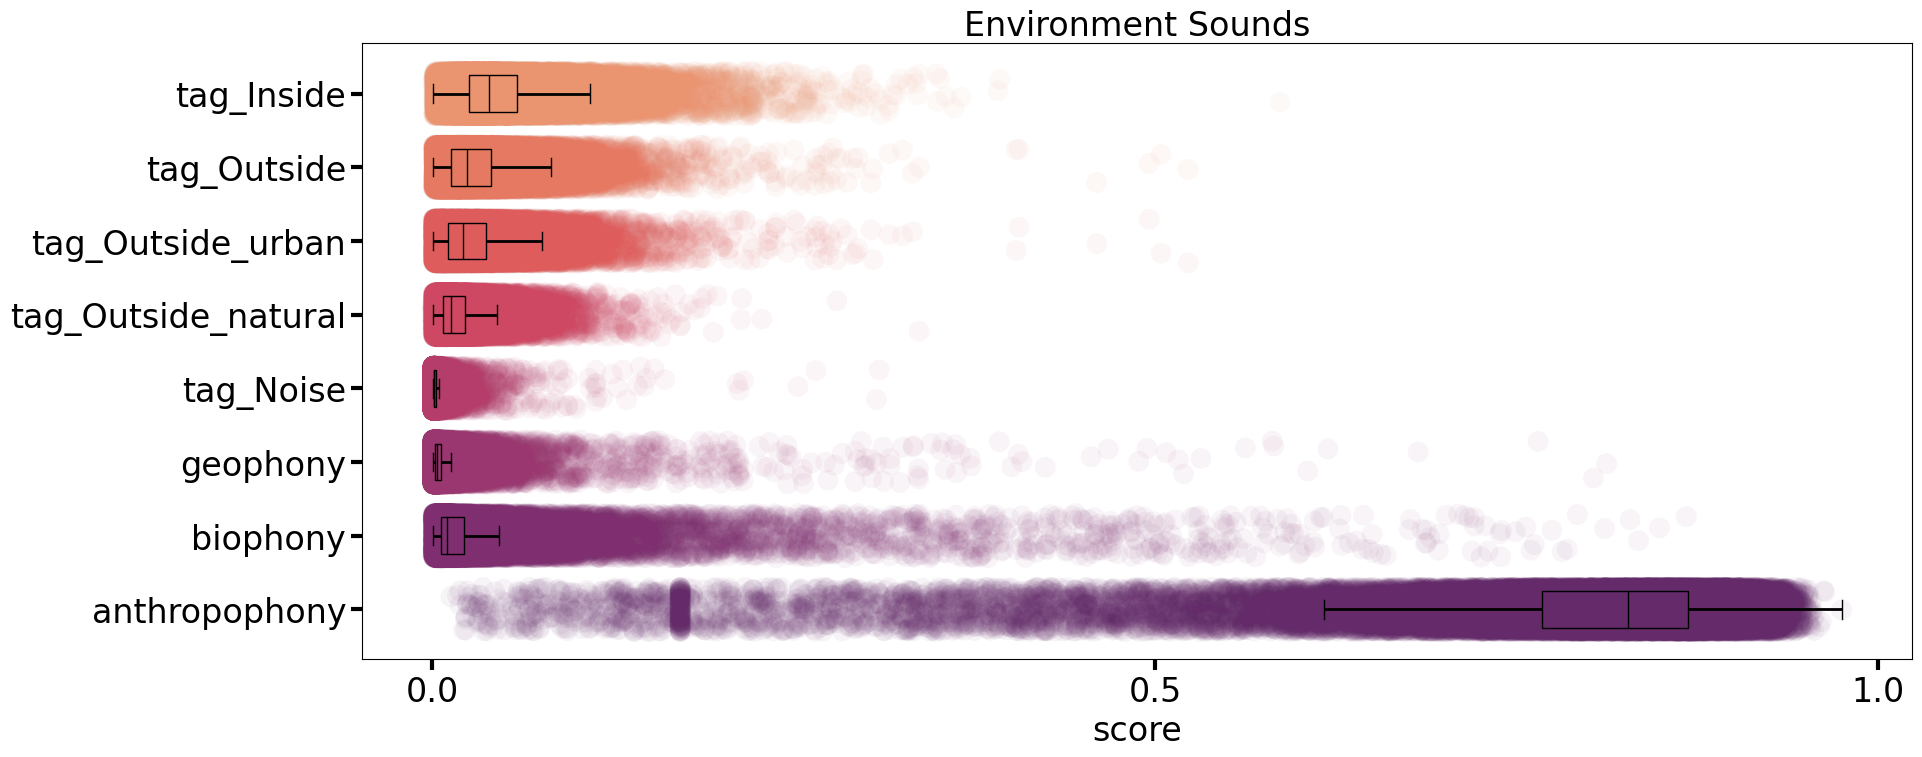

In [62]:
# Environment sounds

tags= [
 'tag_Inside',
 'tag_Outside',
 'tag_Outside_urban',
 'tag_Outside_natural',
 'tag_Noise',
 'geophony',
 'biophony',
 'anthropophony',
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Environment Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Environment_sounds.png", bbox_inches='tight')
    
plt.plot()



[]

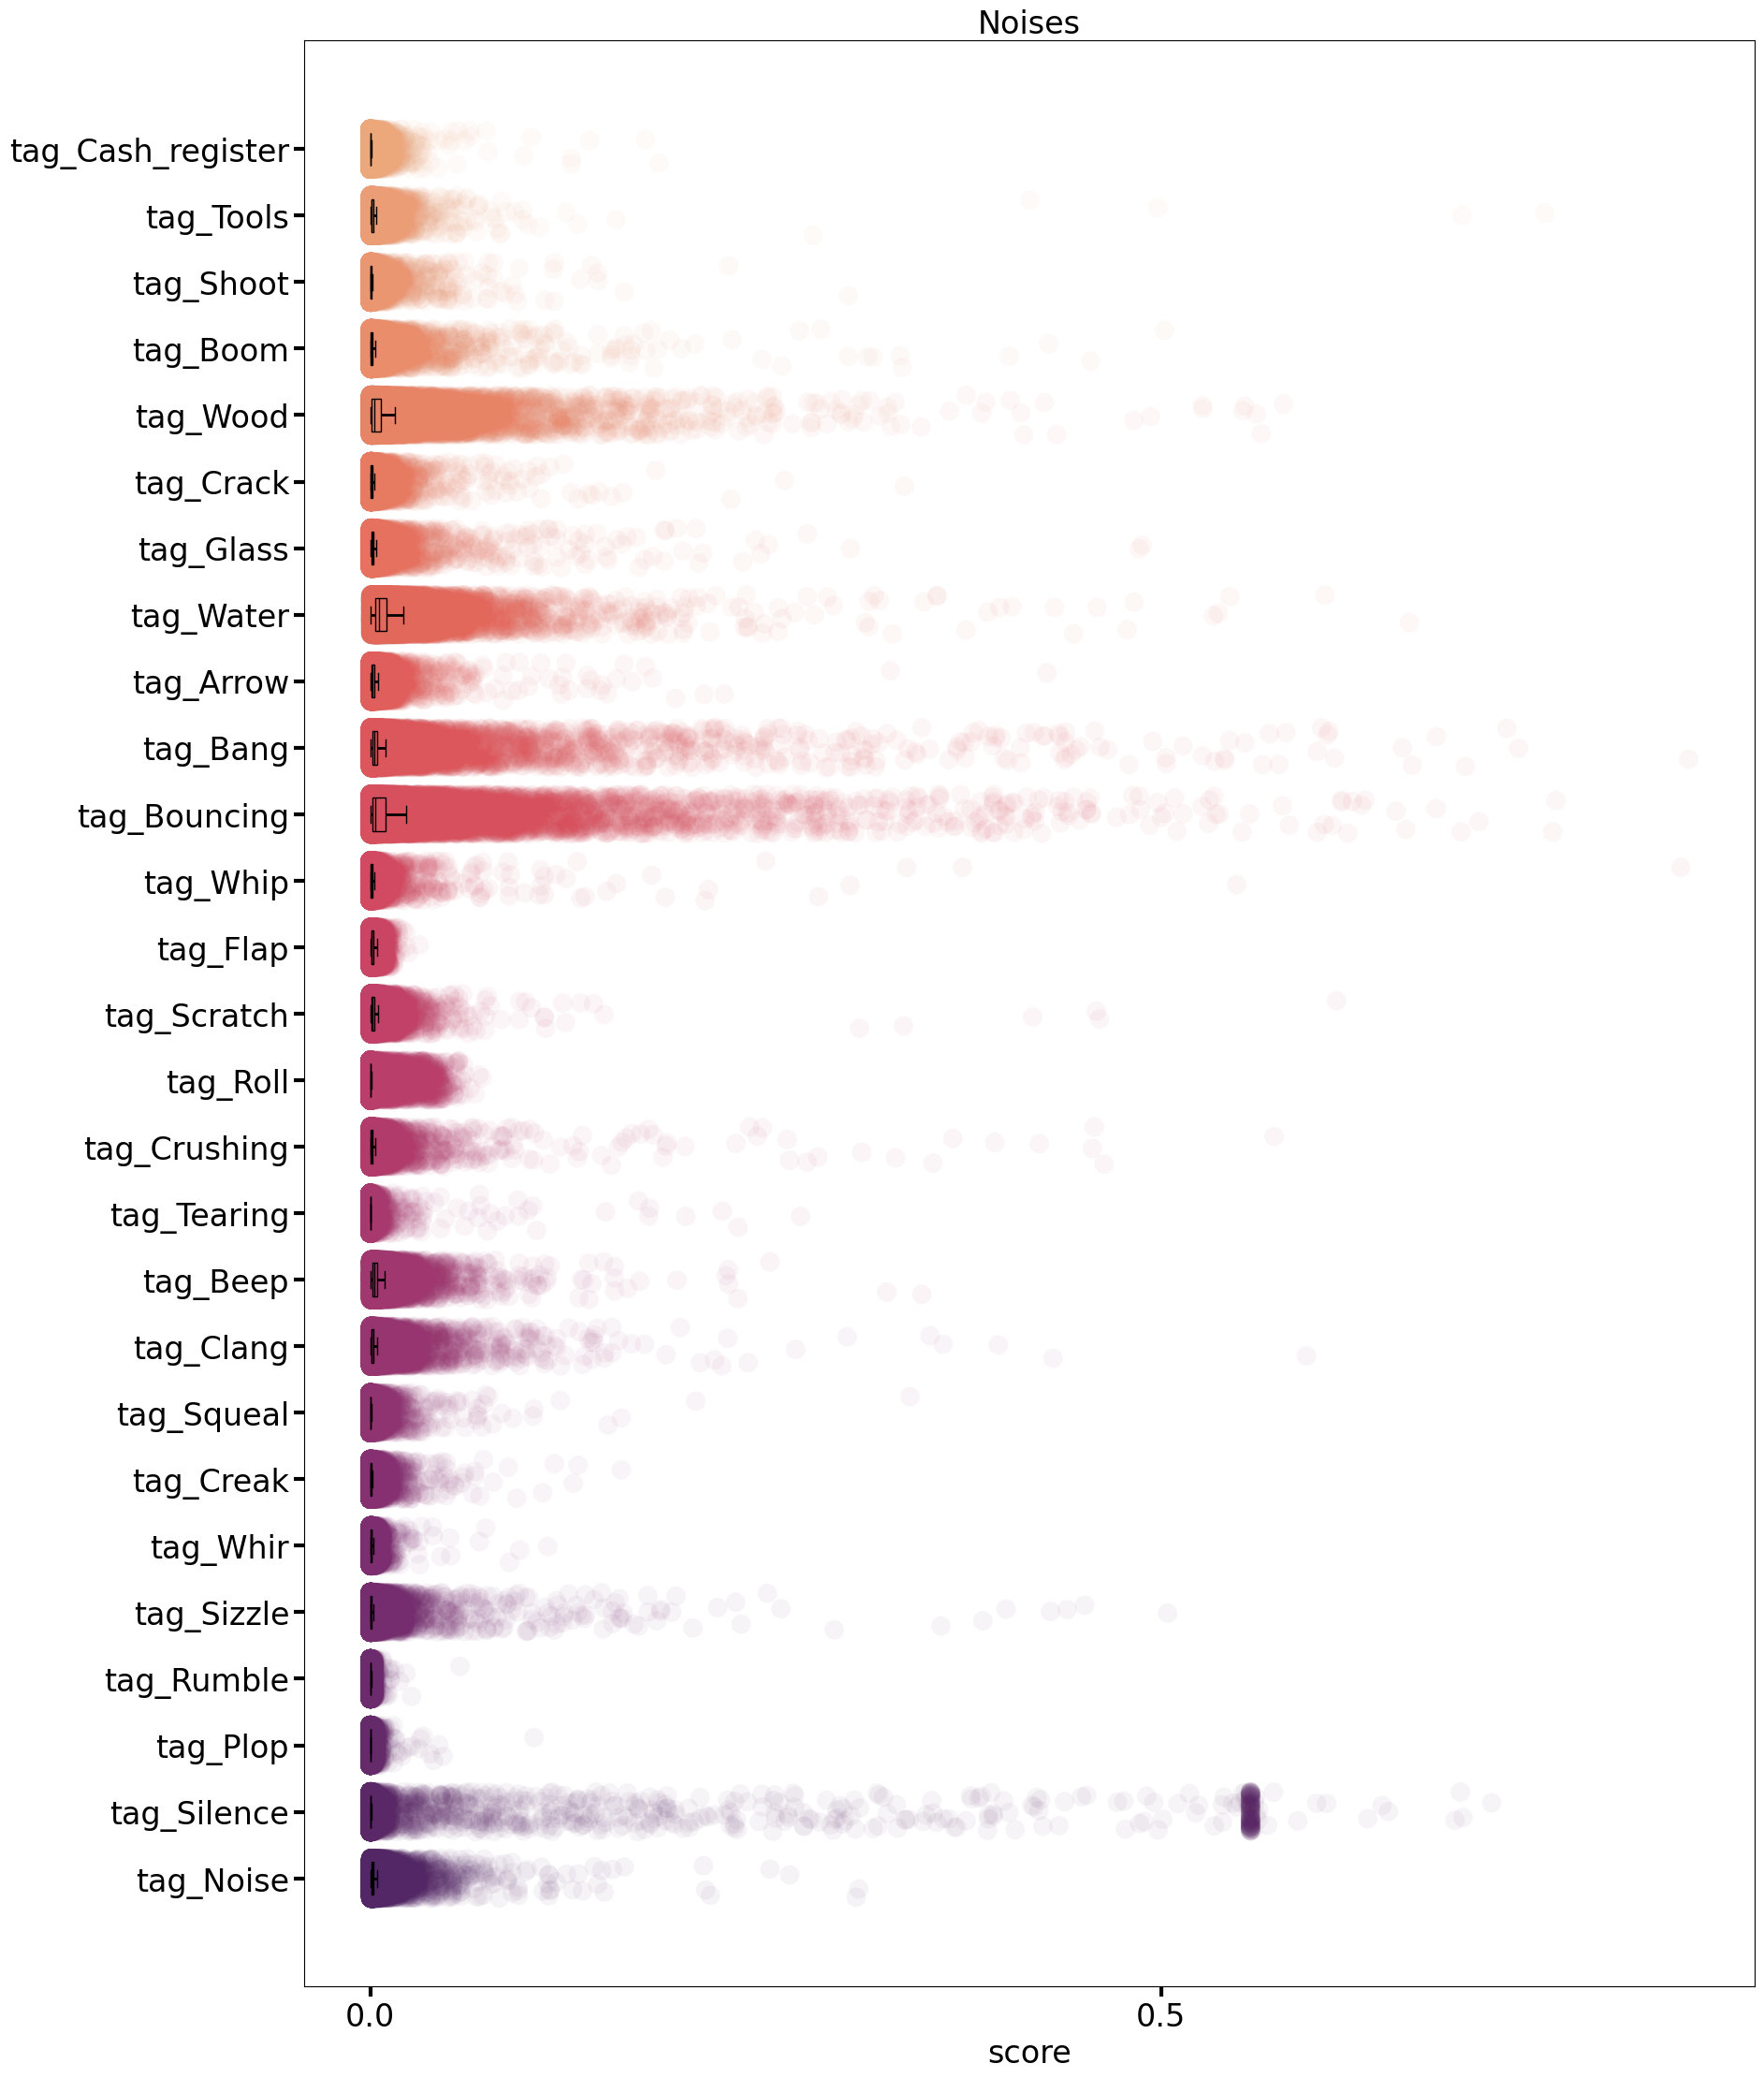

In [63]:
# Noises

tags= [
 'tag_Cash_register',
 'tag_Tools',
 'tag_Shoot',
 'tag_Boom',
 'tag_Wood',
 'tag_Crack',
 'tag_Glass',
 'tag_Water',
 'tag_Arrow',
 'tag_Bang',
 'tag_Bouncing',
 'tag_Whip',
 'tag_Flap',
 'tag_Scratch',
 'tag_Roll',
 'tag_Crushing',
 'tag_Tearing',
 'tag_Beep',
 'tag_Clang',
 'tag_Squeal',
 'tag_Creak',
 'tag_Whir',
 'tag_Sizzle',
 'tag_Rumble',
 'tag_Plop',
 'tag_Silence',
 'tag_Noise',    
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Noises")
if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Noises.png", bbox_inches='tight')
    
plt.plot()


[]

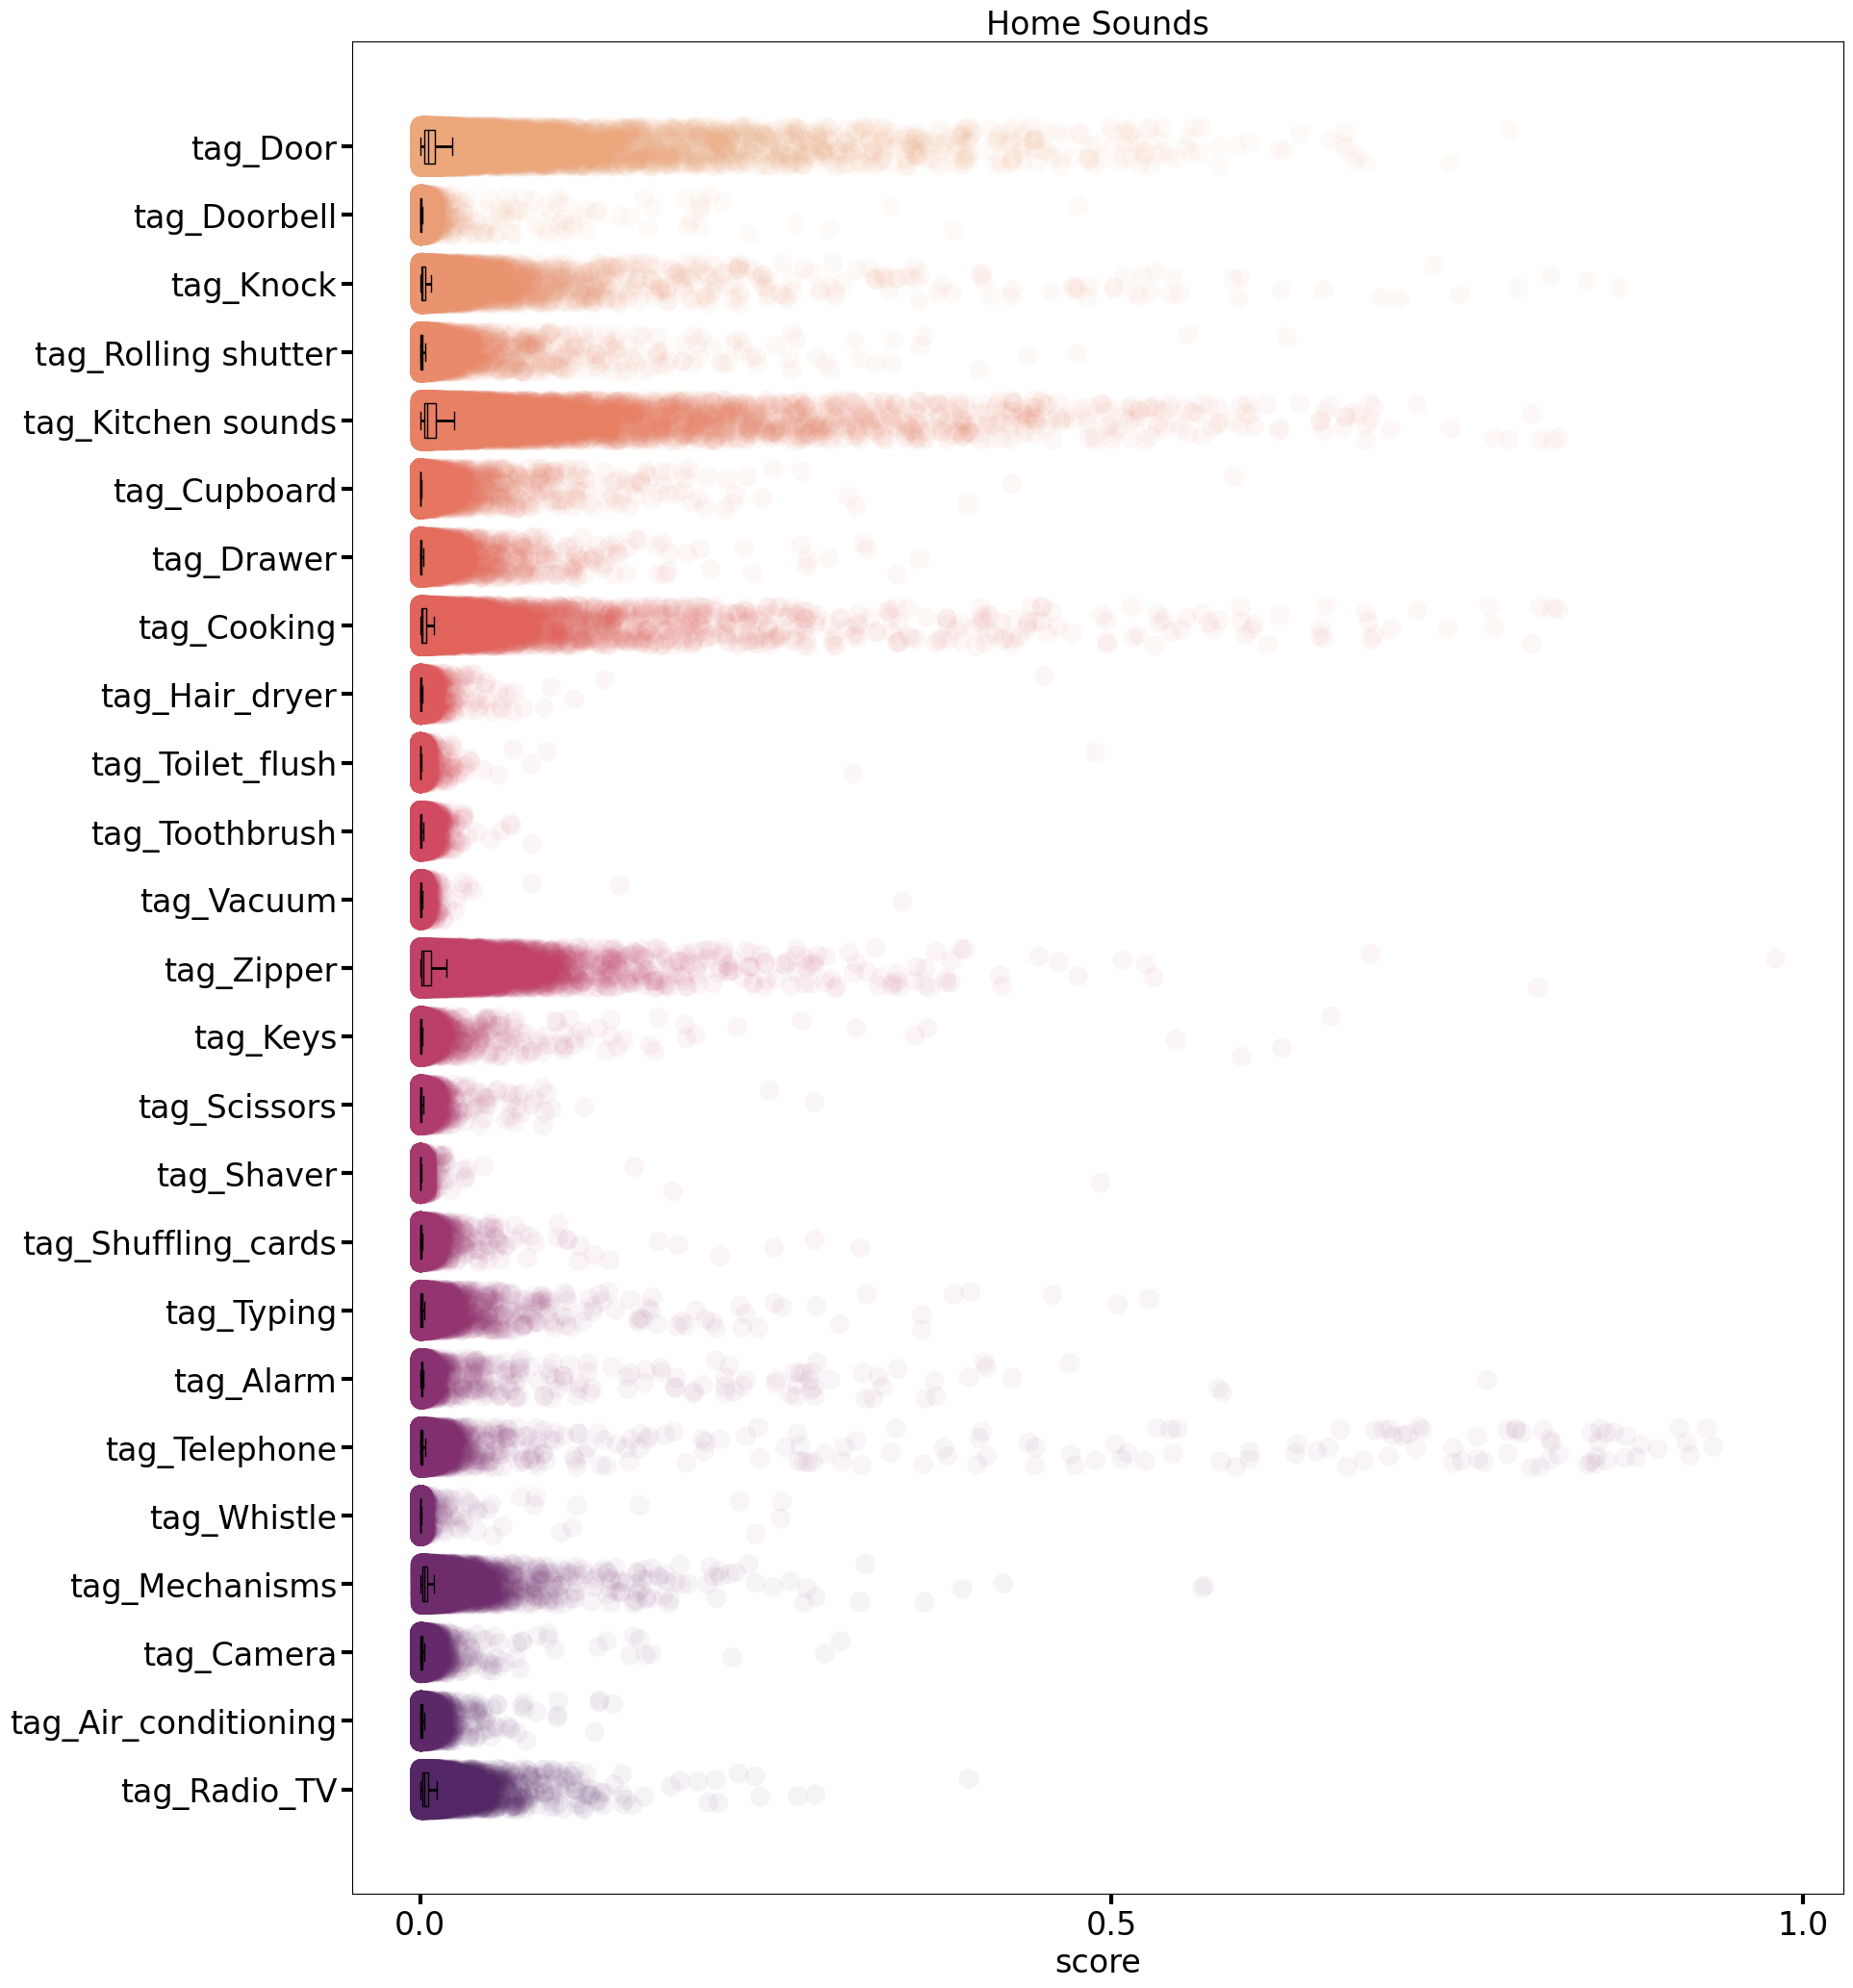

In [64]:
# Home Sounds

tags= [
 'tag_Door',
 'tag_Doorbell',
 'tag_Knock',
 'tag_Rolling shutter',
 'tag_Kitchen sounds',
 'tag_Cupboard',
 'tag_Drawer',
 'tag_Cooking',
 'tag_Hair_dryer',
 'tag_Toilet_flush',
 'tag_Toothbrush',
 'tag_Vacuum',
 'tag_Zipper',
 'tag_Keys',
 'tag_Scissors',
 'tag_Shaver',
 'tag_Shuffling_cards',
 'tag_Typing',
 'tag_Alarm',
 'tag_Telephone',
 'tag_Whistle',
 'tag_Mechanisms',
 'tag_Camera',
 'tag_Air_conditioning',
 'tag_Radio_TV',    
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Home Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Home_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Home_sounds.png", bbox_inches='tight')
    
plt.plot()


[]

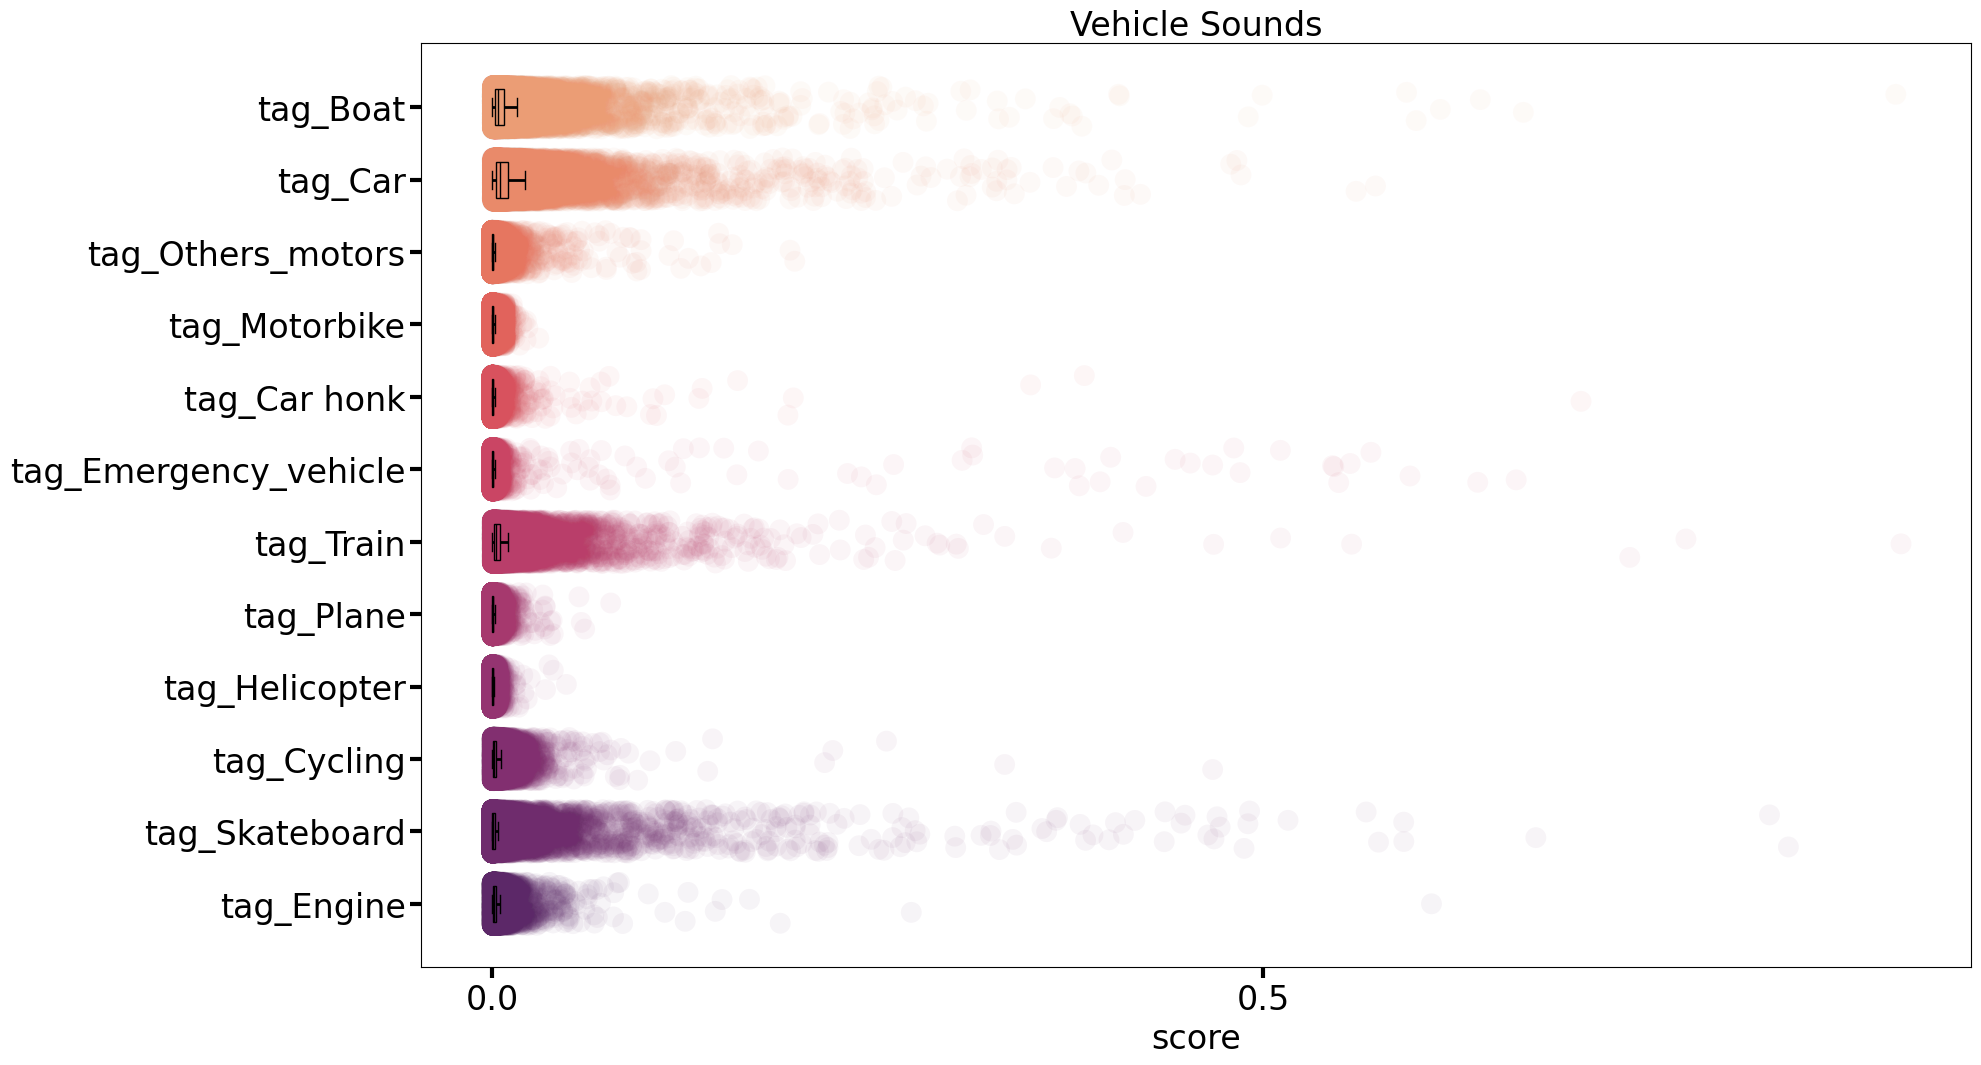

In [65]:
# Vehicle sounds

tags= [
 'tag_Boat',
 'tag_Car',
 'tag_Others_motors',
 'tag_Motorbike',
 'tag_Car honk',
 'tag_Emergency_vehicle',
 'tag_Train',
 'tag_Plane',
 'tag_Helicopter',
 'tag_Cycling',
 'tag_Skateboard',
 'tag_Engine',
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Vehicle Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Vehicle_sounds.png", bbox_inches='tight')
    
plt.plot()


[]

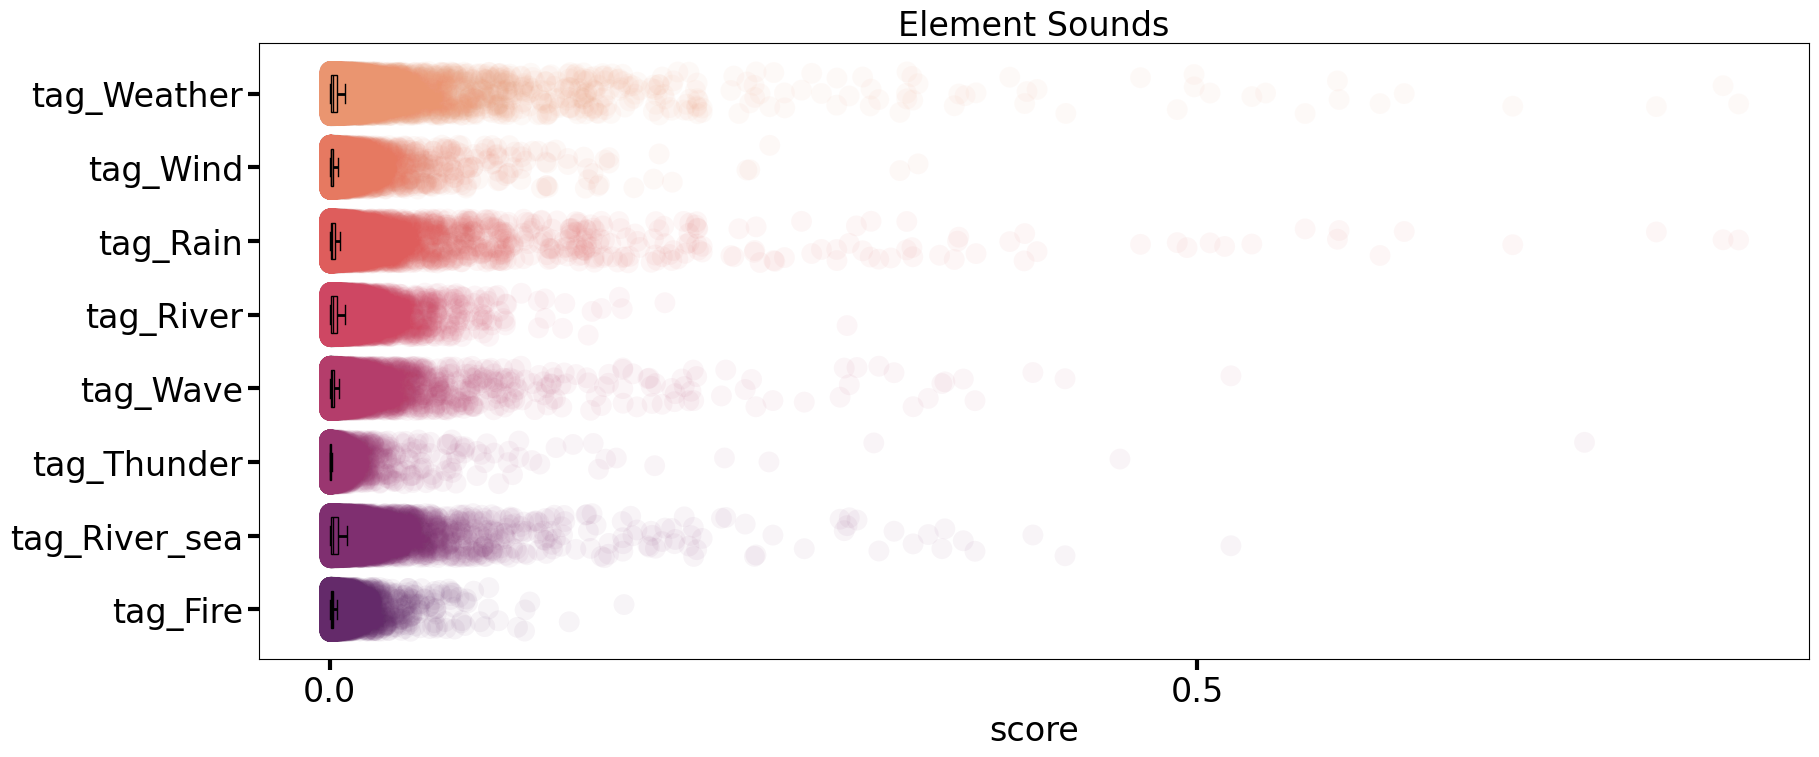

In [66]:


# Elements sounds

tags= [
 'tag_Weather',
 'tag_Wind',
 'tag_Rain',
 'tag_River',
 'tag_Wave',
 'tag_Thunder',
 'tag_River_sea',
 'tag_Fire',
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Element Sounds")
if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Element_sounds.png", bbox_inches='tight')
    
plt.plot()




[]

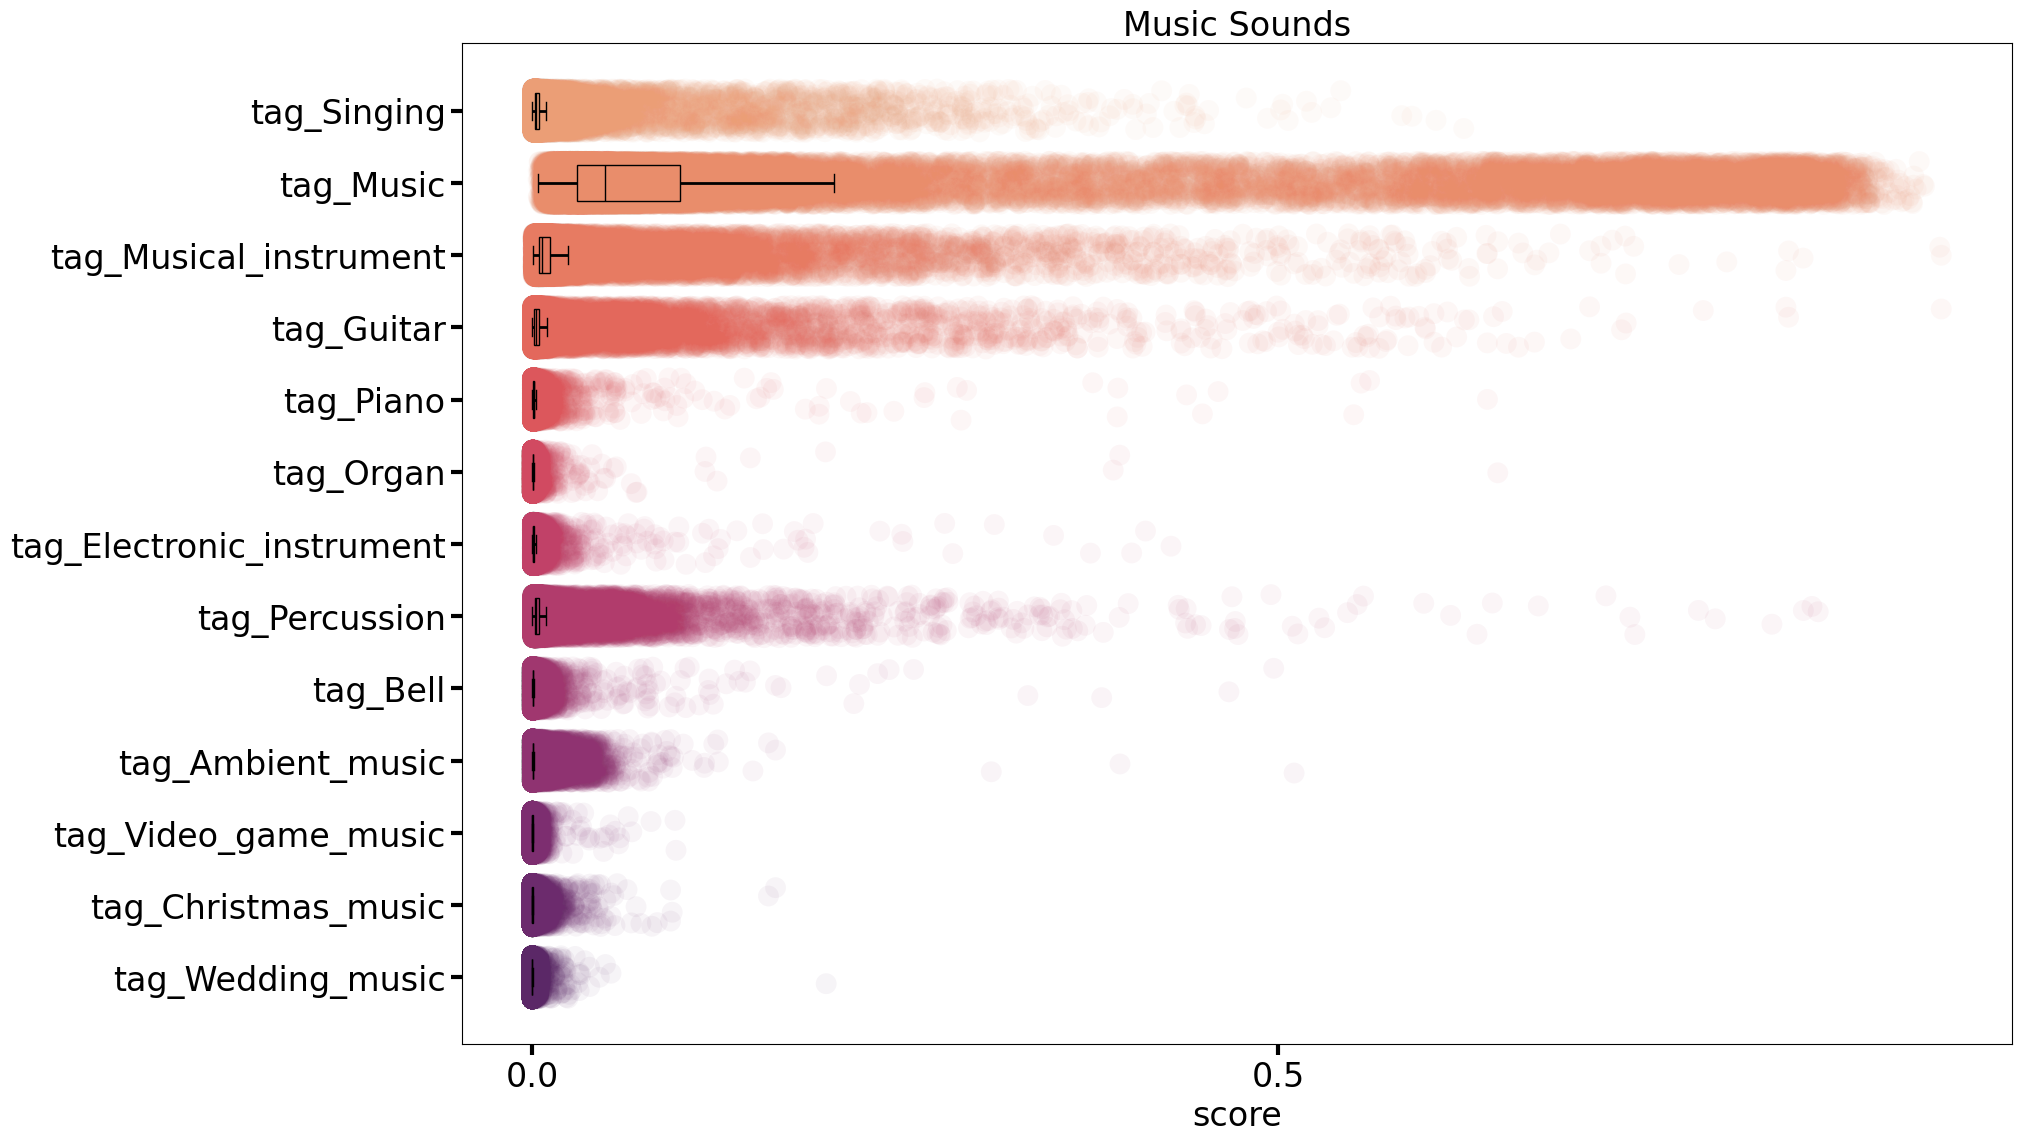

In [67]:
# Music sounds

tags= [
 'tag_Singing',
 'tag_Music',
 'tag_Musical_instrument',
 'tag_Guitar',
 'tag_Piano',
 'tag_Organ',
 'tag_Electronic_instrument',
 'tag_Percussion',
 'tag_Bell',
 'tag_Ambient_music',
 'tag_Video_game_music',
 'tag_Christmas_music',
 'tag_Wedding_music',
]


df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Music Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Music_sounds.png", bbox_inches='tight')
    
plt.plot()




[]

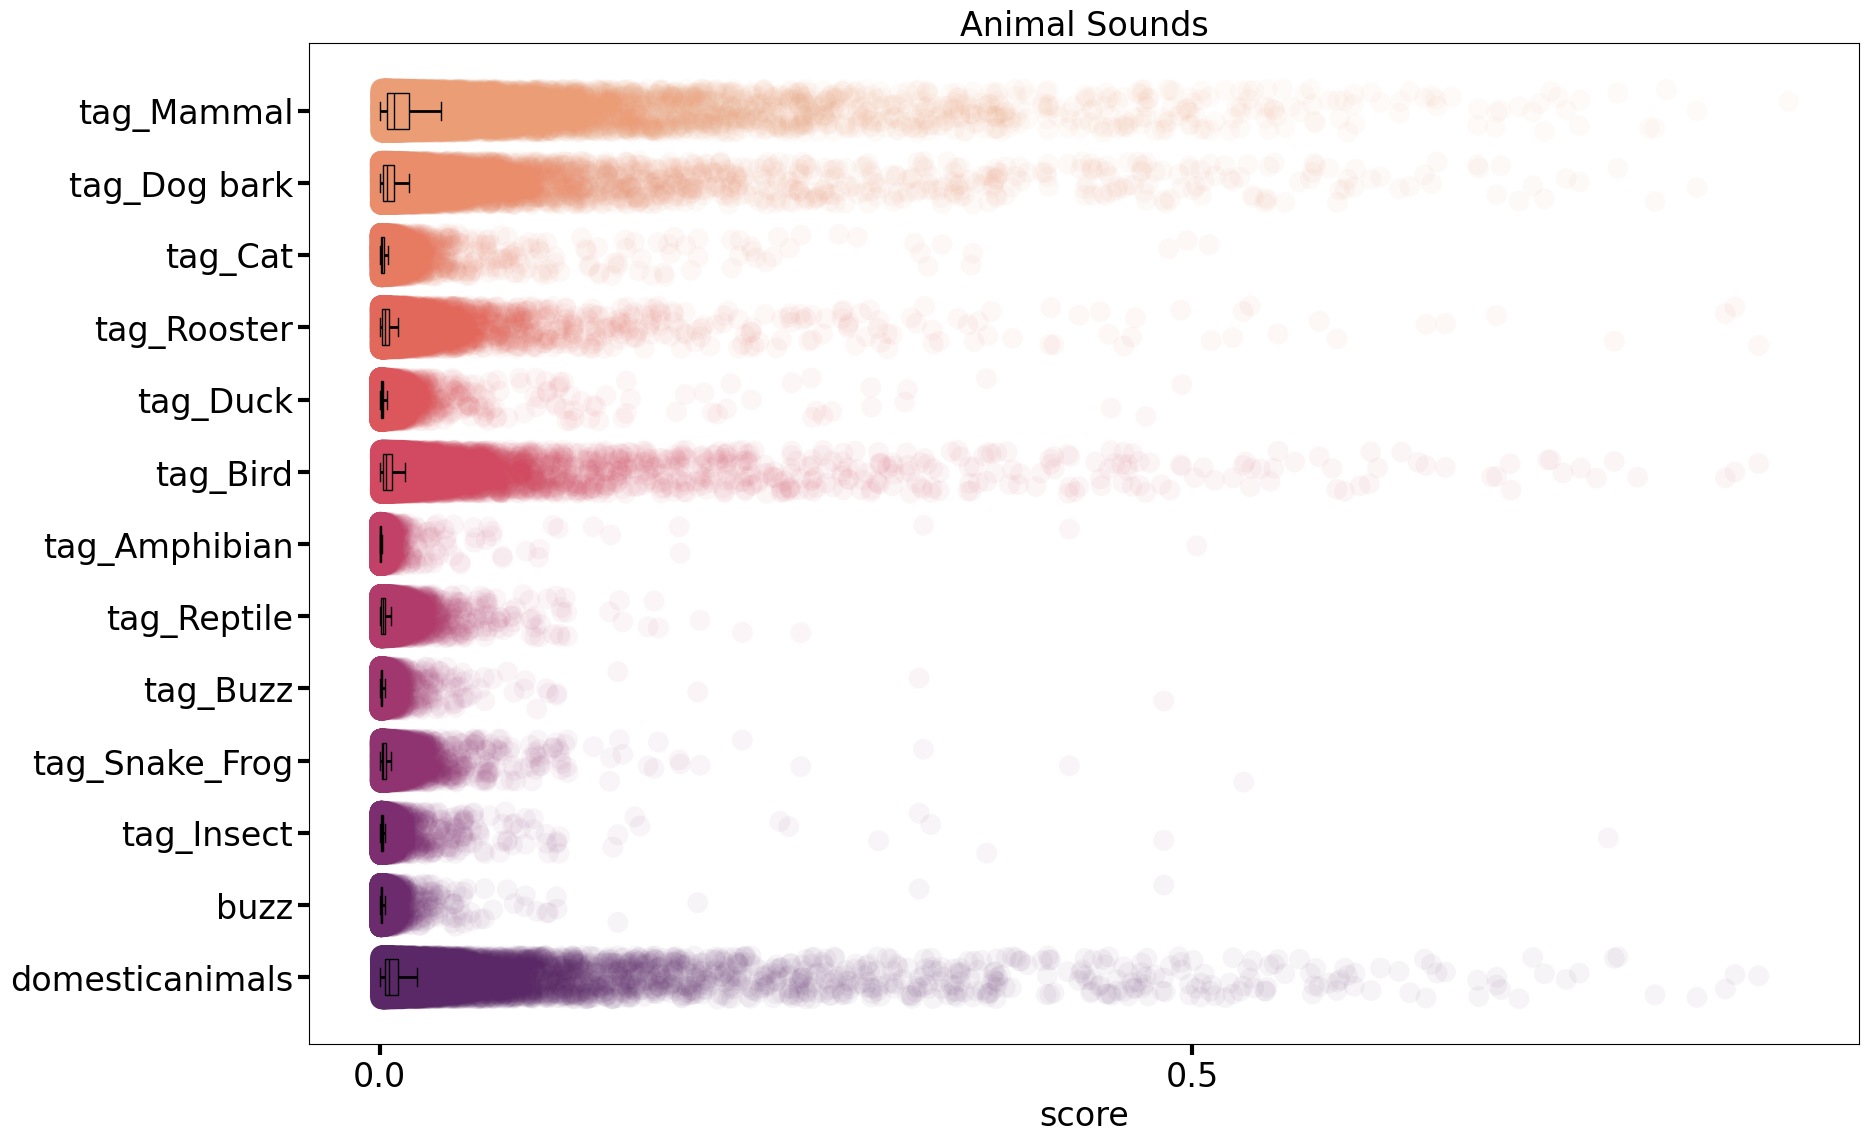

In [68]:
# Animal sounds

tags= [
 'tag_Mammal',
 'tag_Dog bark',
 'tag_Cat',
 'tag_Rooster',
 'tag_Duck',
 'tag_Bird',
 'tag_Amphibian',
 'tag_Reptile',
 'tag_Buzz',
 'tag_Snake_Frog',
 'tag_Insect', 
 'buzz',
 'domesticanimals',
]


df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Animal Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Animal_sounds.png", bbox_inches='tight')
    
plt.plot()



[]

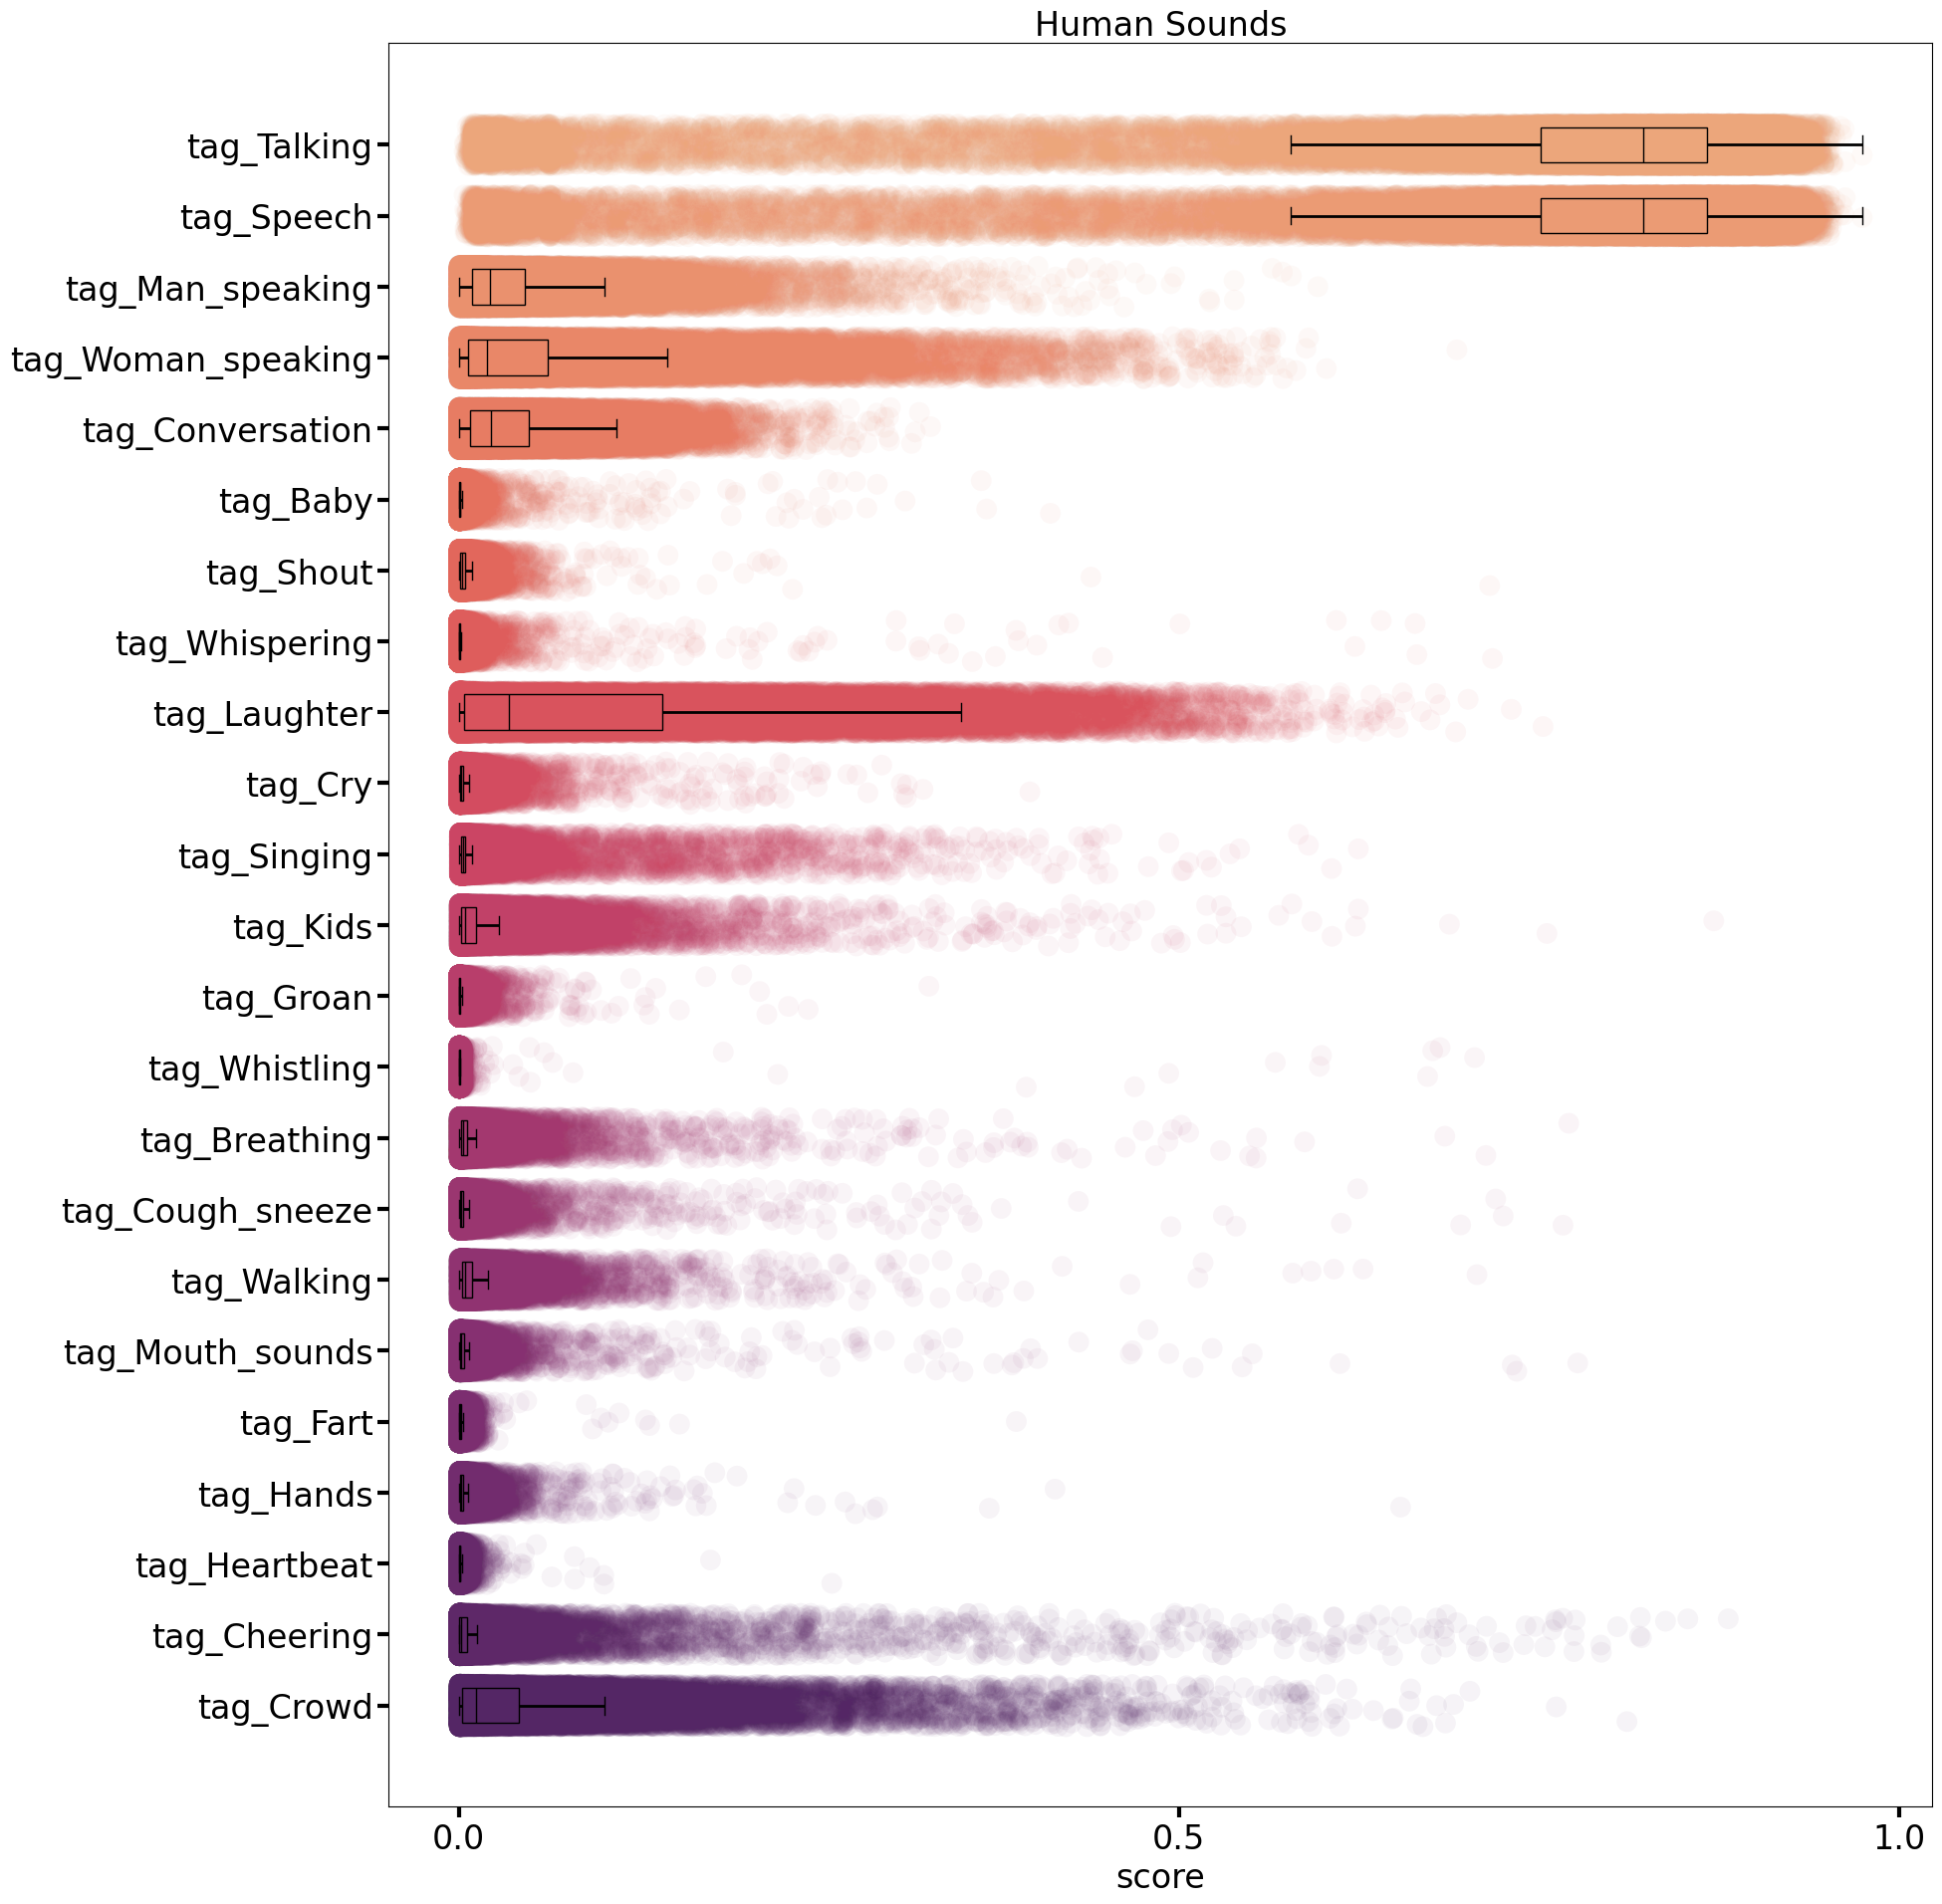

In [69]:
# Human sounds

tags= ['tag_Talking',
 'tag_Speech',
 'tag_Man_speaking',
 'tag_Woman_speaking',
 'tag_Conversation',
 'tag_Baby',
 'tag_Shout',
 'tag_Whispering',
 'tag_Laughter',
 'tag_Cry',
 'tag_Singing',
 'tag_Kids',
 'tag_Groan',
 'tag_Whistling',
 'tag_Breathing',
 'tag_Cough_sneeze',
 'tag_Walking',
 'tag_Mouth_sounds',
 'tag_Fart',
 'tag_Hands',
 'tag_Heartbeat',
 'tag_Cheering',
 'tag_Crowd',
]


df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Human Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Human_sounds.png", bbox_inches='tight')
    
plt.plot()


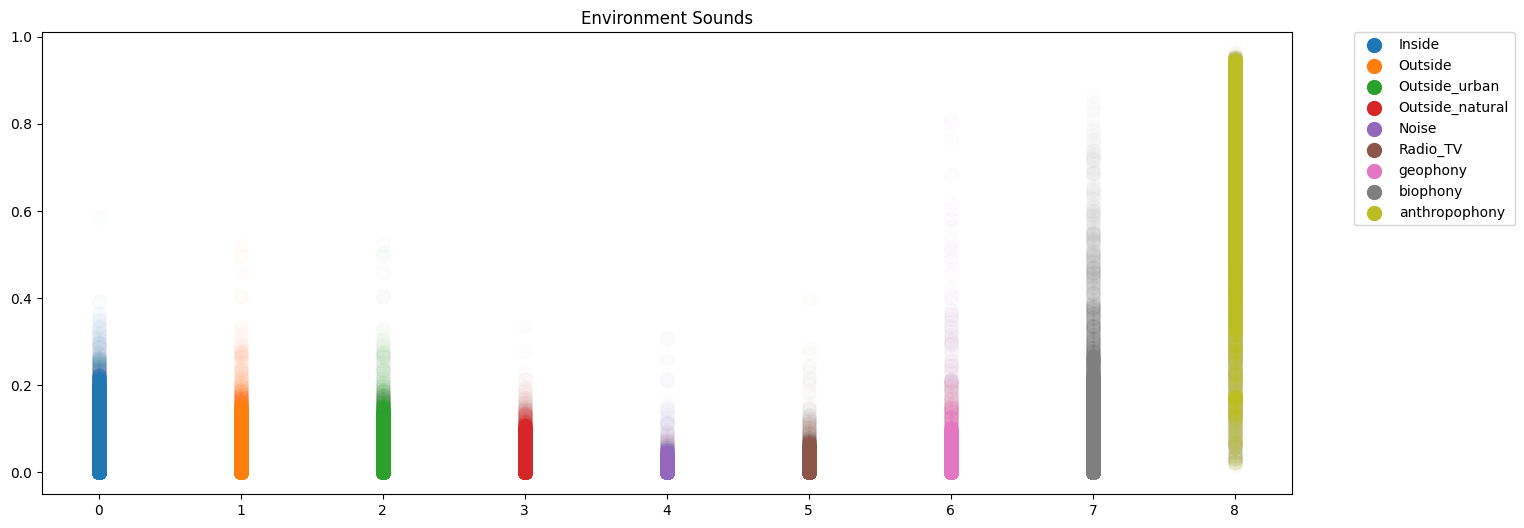

In [65]:
# Environment sounds

environ_tags= [
 'tag_Inside',
 'tag_Outside',
 'tag_Outside_urban',
 'tag_Outside_natural',
 'tag_Noise',
 'geophony',
 'biophony',
 'anthropophony',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(environ_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Environment Sounds")
plt.show()

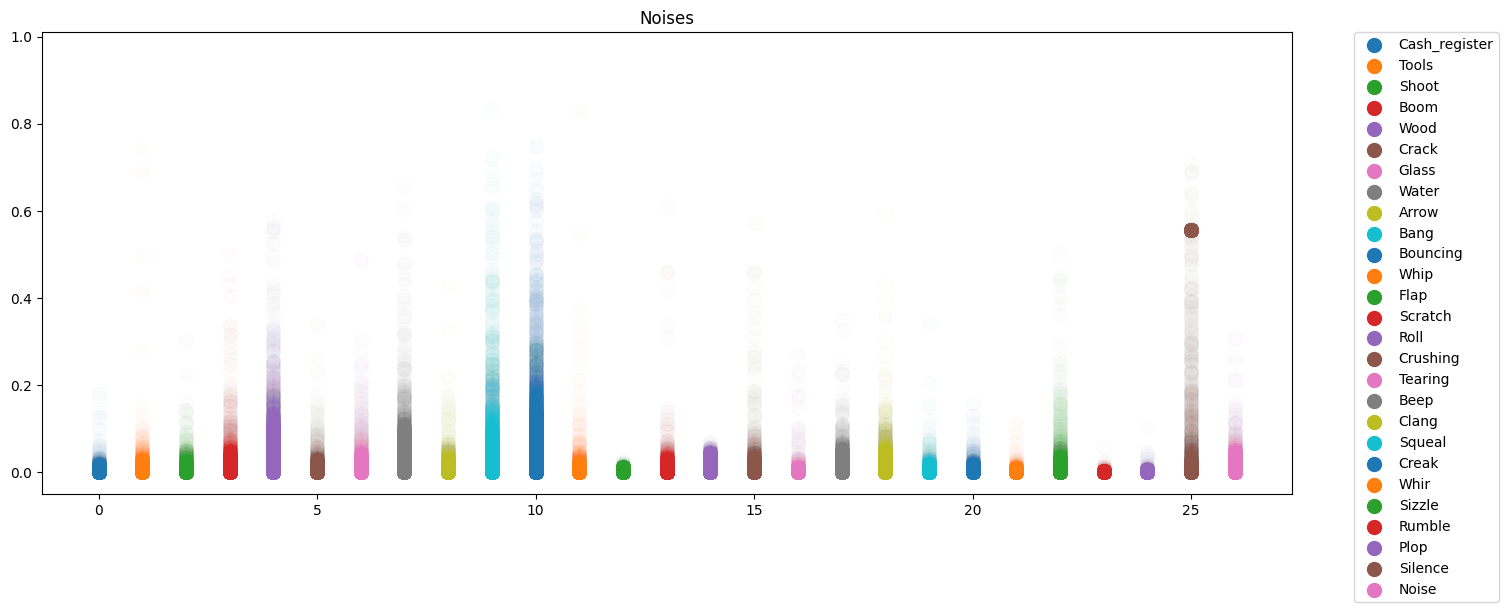

In [64]:
# Noise sounds

noises_tags= [
 'tag_Cash_register',
 'tag_Tools',
 'tag_Shoot',
 'tag_Boom',
 'tag_Wood',
 'tag_Crack',
 'tag_Glass',
 'tag_Water',
 'tag_Arrow',
 'tag_Bang',
 'tag_Bouncing',
 'tag_Whip',
 'tag_Flap',
 'tag_Scratch',
 'tag_Roll',
 'tag_Crushing',
 'tag_Tearing',
 'tag_Beep',
 'tag_Clang',
 'tag_Squeal',
 'tag_Creak',
 'tag_Whir',
 'tag_Sizzle',
 'tag_Rumble',
 'tag_Plop',
 'tag_Silence',
 'tag_Noise',    
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(noises_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Noises")
plt.show()

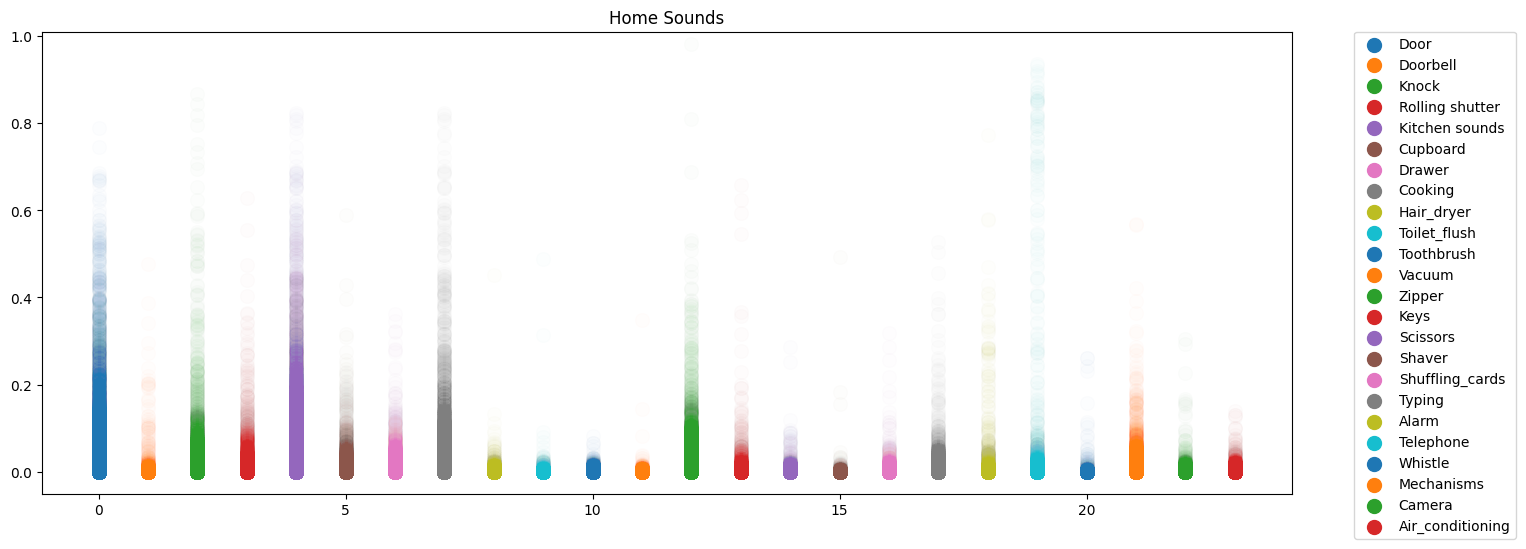

In [60]:
# Home sounds

home_tags= [
 'tag_Door',
 'tag_Doorbell',
 'tag_Knock',
 'tag_Rolling shutter',
 'tag_Kitchen sounds',
 'tag_Cupboard',
 'tag_Drawer',
 'tag_Cooking',
 'tag_Hair_dryer',
 'tag_Toilet_flush',
 'tag_Toothbrush',
 'tag_Vacuum',
 'tag_Zipper',
 'tag_Keys',
 'tag_Scissors',
 'tag_Shaver',
 'tag_Shuffling_cards',
 'tag_Typing',
 'tag_Alarm',
 'tag_Telephone',
 'tag_Whistle',
 'tag_Mechanisms',
 'tag_Camera',
 'tag_Air_conditioning',
 'tag_Radio_TV',    
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(home_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Home Sounds")
plt.show()


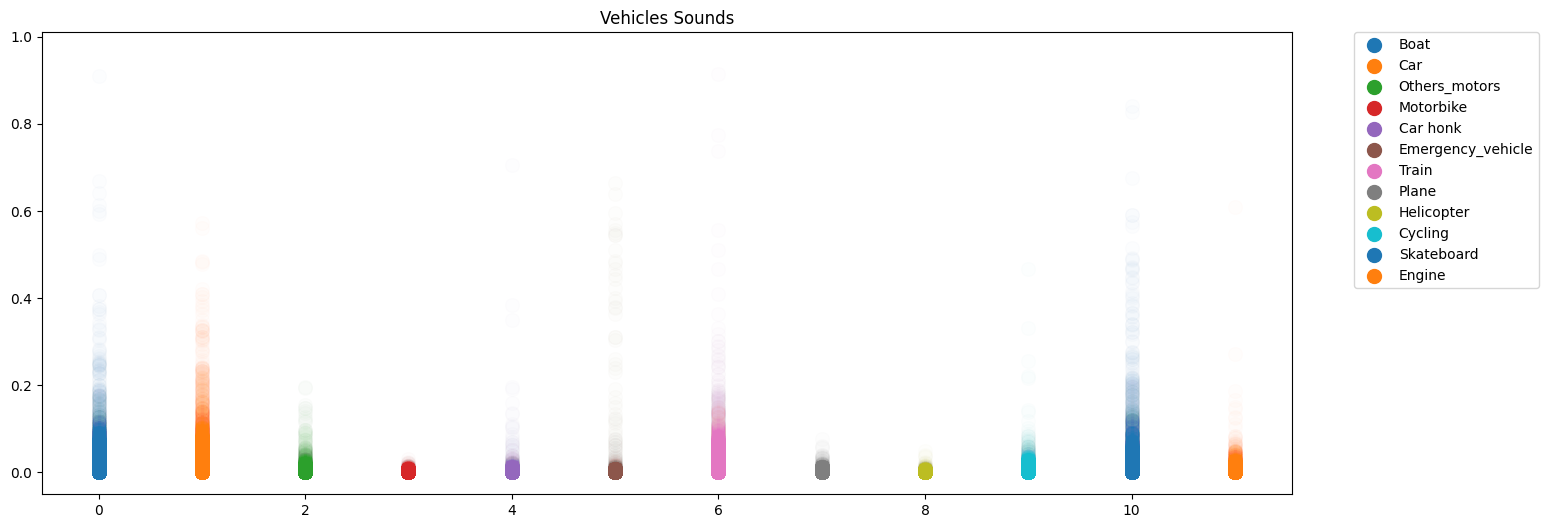

In [58]:
# Vehicle sounds

vehicles_tags= [
 'tag_Boat',
 'tag_Car',
 'tag_Others_motors',
 'tag_Motorbike',
 'tag_Car honk',
 'tag_Emergency_vehicle',
 'tag_Train',
 'tag_Plane',
 'tag_Helicopter',
 'tag_Cycling',
 'tag_Skateboard',
 'tag_Engine',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(vehicles_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Vehicles Sounds")
plt.show()


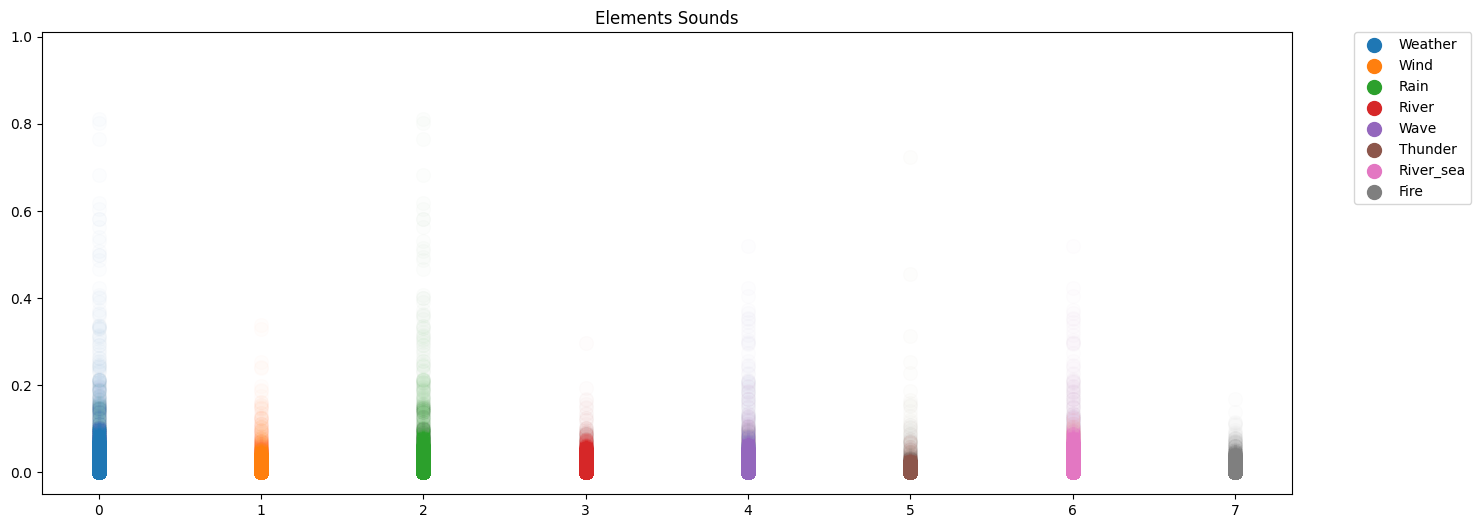

In [57]:
# Elements sounds

elements_tags= [
 'tag_Weather',
 'tag_Wind',
 'tag_Rain',
 'tag_River',
 'tag_Wave',
 'tag_Thunder',
 'tag_River_sea',
 'tag_Fire',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(elements_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Elements Sounds")
plt.show()


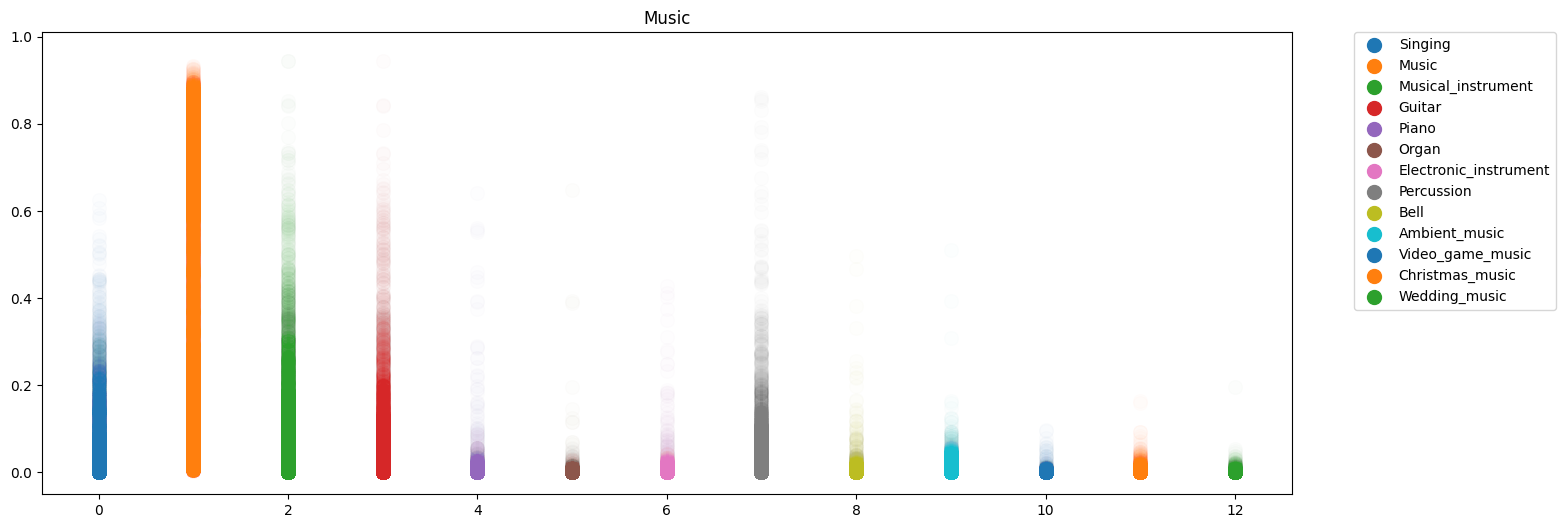

In [55]:
# Music sounds

music_tags= [
 'tag_Singing',
 'tag_Music',
 'tag_Musical_instrument',
 'tag_Guitar',
 'tag_Piano',
 'tag_Organ',
 'tag_Electronic_instrument',
 'tag_Percussion',
 'tag_Bell',
 'tag_Ambient_music',
 'tag_Video_game_music',
 'tag_Christmas_music',
 'tag_Wedding_music',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(music_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Music")
plt.show()


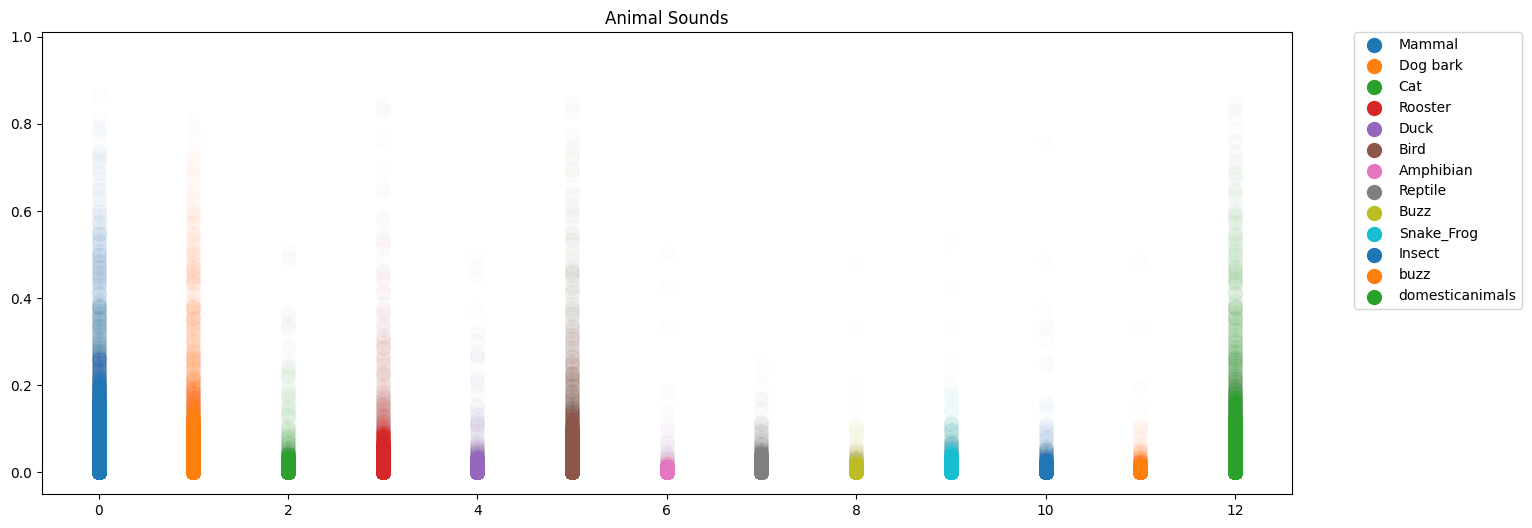

In [59]:
# Animal sounds

animal_tags= [
 'tag_Mammal',
 'tag_Dog bark',
 'tag_Cat',
 'tag_Rooster',
 'tag_Duck',
 'tag_Bird',
 'tag_Amphibian',
 'tag_Reptile',
 'tag_Buzz',
 'tag_Snake_Frog',
 'tag_Insect', 
 'buzz',
 'domesticanimals',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(animal_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Animal Sounds")
plt.show()


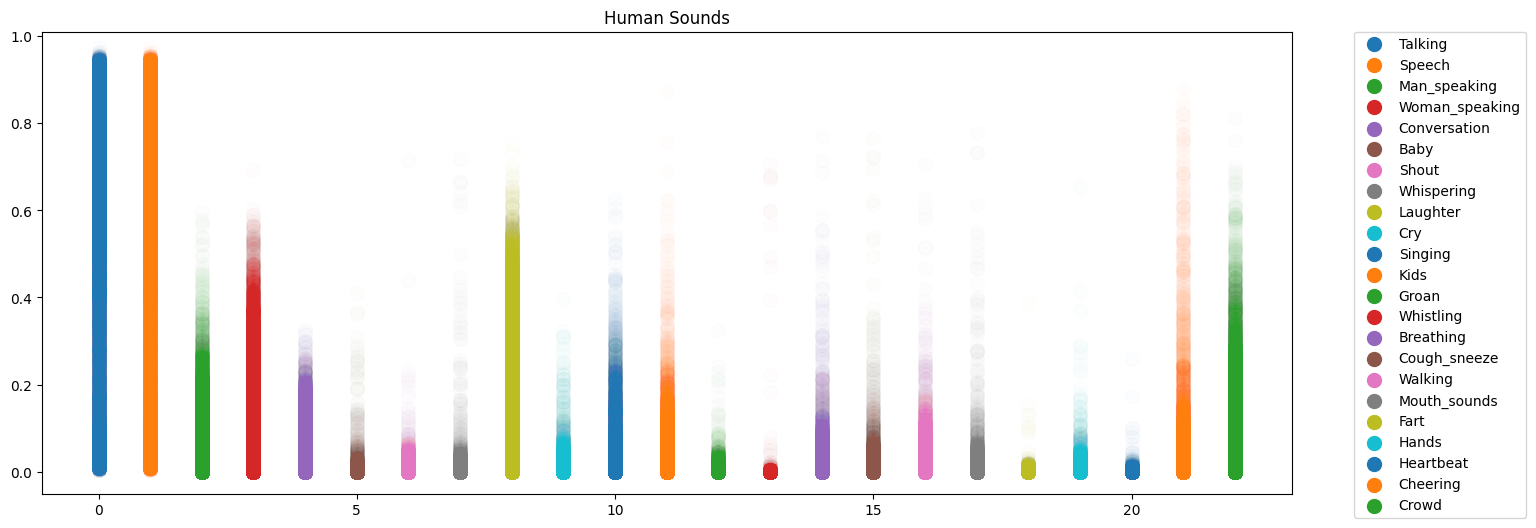

In [50]:
# Human sounds

talk_tags= ['tag_Talking',
 'tag_Speech',
 'tag_Man_speaking',
 'tag_Woman_speaking',
 'tag_Conversation',
 'tag_Baby',
 'tag_Shout',
 'tag_Whispering',
 'tag_Laughter',
 'tag_Cry',
 'tag_Singing',
 'tag_Kids',
 'tag_Groan',
 'tag_Whistling',
 'tag_Breathing',
 'tag_Cough_sneeze',
 'tag_Walking',
 'tag_Mouth_sounds',
 'tag_Fart',
 'tag_Hands',
 'tag_Heartbeat',
 'tag_Cheering',
 'tag_Crowd',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(talk_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Human Sounds")
plt.show()

